# **Semana 7: Redes Neuronales Recurrentes y Series de Tiempo**

Este cuaderno contiene explicaciones y código práctico sobre el funcionamiento de las Redes Neuronales Recurrentes (RNN, LSTM y GRU) y su aplicación en dos tareas:
1. **Clasificación de nombres por idioma (NLP a nivel de caracteres)** en PyTorch.
2. **Predicción de series de tiempo (PM2.5 en Beijing)** usando LSTM univariadas y multivariadas.


# **1. Configuración del Entorno y Descarga de Datos**


In [1]:
# Instalación de librerías esenciales (silenciosa)
!pip install -q unidecode statsmodels scikit-learn tqdm


In [2]:
# Importaciones unificadas de todo el cuaderno
import os
import sys
import random
import zipfile
import urllib.request
import urllib.error
import shutil
from string import ascii_letters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score
from tqdm.notebook import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from statsmodels.tsa.seasonal import STL


In [3]:
# Validación del entorno de ejecución y GPU
esta_en_colab = 'google.colab' in sys.modules
print(f"¿Entorno de ejecución de Google Colab?: {esta_en_colab}")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento asignado por PyTorch: {dispositivo}")

if torch.cuda.is_available():
    nombre_gpu = torch.cuda.get_device_name(0)
    memoria_total_gpu = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU detectada: {nombre_gpu}")
    print(f"Memoria total de GPU: {memoria_total_gpu:.2f} GB")
else:
    print("No se dispone de GPU CUDA. El entrenamiento se realizará en la CPU (puede demorarse más).")


¿Entorno de ejecución de Google Colab?: False
Dispositivo de entrenamiento asignado por PyTorch: cuda
GPU detectada: NVIDIA RTX A5000
Memoria total de GPU: 23.99 GB


In [4]:
# Descargador y extractor robusto con manejo de errores de conexión (400-500)
def descargar_y_guardar(url, ruta_destino, etiqueta="Archivo"):
    print(f"Descargando {etiqueta} desde {url}...")
    cabeceras = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    peticion = urllib.request.Request(url, headers=cabeceras)
    try:
        with urllib.request.urlopen(peticion, timeout=30) as respuesta, open(ruta_destino, 'wb') as archivo_salida:
            shutil.copyfileobj(respuesta, archivo_salida)
        print(f"Descarga completada y guardada en: {ruta_destino}")
    except urllib.error.HTTPError as e:
        print(f"[ERROR HTTP {e.code}]: No se pudo descargar el archivo. Razón: {e.reason}")
        raise
    except urllib.error.URLError as e:
        print(f"[ERROR DE CONEXIÓN/URL]: Error de red. Razón: {e.reason}")
        raise
    except Exception as e:
        print(f"[ERROR INESPERADO]: {str(e)}")
        raise

# Crear carpeta para almacenar datos de forma relativa
os.makedirs("data", exist_ok=True)

# 1. Descarga y extracción del dataset de Nombres
directorio_nombres = "data/names"
if not os.path.exists(directorio_nombres) or len(os.listdir(directorio_nombres)) == 0:
    archivo_zip_nombres = "data/nombres_temporal.zip"
    url_nombres = "https://download.pytorch.org/tutorial/data.zip"
    try:
        descargar_y_guardar(url_nombres, archivo_zip_nombres, "Dataset de Nombres (PyTorch)")
        print("Descomprimiendo el archivo zip de nombres...")
        with zipfile.ZipFile(archivo_zip_nombres, 'r') as ref_zip:
            # El ZIP contiene la carpeta 'data/names' interna
            ref_zip.extractall(".")
        print("Dataset de nombres extraído correctamente en 'data/names/'.")
    except Exception as e:
        print(f"Error al procesar el dataset de nombres: {e}")
    finally:
        if os.path.exists(archivo_zip_nombres):
            os.remove(archivo_zip_nombres)
else:
    print("El dataset de nombres ya está presente en 'data/names/'.")

# 2. Descarga y extracción del dataset de Calidad del Aire (Beijing)
ruta_csv_aire = "data/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
if not os.path.exists(ruta_csv_aire):
    archivo_zip_aire = "data/aire_temporal.zip"
    url_aire = "https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip"
    try:
        descargar_y_guardar(url_aire, archivo_zip_aire, "Dataset de Calidad del Aire de Beijing (UCI)")
        print("Extrayendo únicamente la estación Aotizhongxin...")
        nombre_miembro_csv = "PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
        with zipfile.ZipFile(archivo_zip_aire, 'r') as ref_zip:
            with ref_zip.open(nombre_miembro_csv) as origen, open(ruta_csv_aire, 'wb') as destino:
                shutil.copyfileobj(origen, destino)
        print(f"Estación Aotizhongxin extraída con éxito en: {ruta_csv_aire}")
    except Exception as e:
        print(f"Error al procesar el dataset de calidad del aire: {e}")
    finally:
        if os.path.exists(archivo_zip_aire):
            os.remove(archivo_zip_aire)
else:
    print(f"El archivo de calidad del aire ya está presente en: {ruta_csv_aire}")


El dataset de nombres ya está presente en 'data/names/'.
El archivo de calidad del aire ya está presente en: data/PRSA_Data_Aotizhongxin_20130301-20170228.csv


# **2. Parte I: Clasificación de Nombres por Idioma**

Clasificaremos nombres de personas en sus respectivos idiomas utilizando modelos RNN (construida a mano), LSTM y GRU en PyTorch, y compararemos su desempeño mediante la métrica F1-Macro.


## **2.1 Preprocesamiento de Datos**

Prepararemos los datos mediante normalización ASCII, mapeo a un diccionario de caracteres fijos, codificación One-Hot de secuencias y división estratificada en Entrenamiento (80%), Validación (10%) y Prueba (10%).


In [5]:
# Configuración del vocabulario
letras_permitidas = ascii_letters + " ,.:;-'"
num_caracteres = len(letras_permitidas)

# Diccionario de carácter a índice
char_a_indice = {char: idx for idx, char in enumerate(letras_permitidas)}

def nombre_a_tensor(nombre):
    """Convierte un nombre a un tensor de tamaño (longitud_nombre, 1, num_caracteres) usando One-Hot."""
    tensor = torch.zeros(len(nombre), 1, num_caracteres)
    for idx, char in enumerate(nombre):
        if char in char_a_indice:
            tensor[idx][0][char_a_indice[char]] = 1.0
    return tensor

# Cargar los archivos de texto de nombres de cada idioma
ruta_nombres = "data/names"
archivos = [f for f in os.listdir(ruta_nombres) if f.endswith(".txt")]

etiquetas_idiomas = {}
nombres_por_idioma = {}
idiomas = []

for idx, archivo in enumerate(archivos):
    idioma = archivo.split(".")[0]
    etiquetas_idiomas[idioma] = torch.tensor([idx], dtype=torch.long)
    idiomas.append(idioma)
    
    with open(os.path.join(ruta_nombres, archivo), 'r', encoding='utf-8') as f:
        # Convertir caracteres especiales a ASCII y remover saltos de línea
        nombres = [unidecode(linea.strip()) for linea in f]
        nombres_por_idioma[idioma] = [n for n in nombres if len(n) > 0]

num_idiomas = len(idiomas)
print(f"Idiomas cargados: {num_idiomas} | Clases: {idiomas}")

# Crear listas de tensores y etiquetas correspondientes
X_tensores = []
y_tensores = []

for idioma, nombres in nombres_por_idioma.items():
    for nombre in nombres:
        try:
            X_tensores.append(nombre_a_tensor(nombre))
            y_tensores.append(etiquetas_idiomas[idioma])
        except KeyError:
            pass

# Obtener representación de etiquetas como enteros para el split estratificado
etiquetas_enteras = [int(lbl.item()) for lbl in y_tensores]

# Primera división: 90% entrenamiento/validación y 10% prueba final
X_temp, X_test, y_temp, y_test = train_test_split(
    X_tensores,
    y_tensores,
    test_size=0.1,
    stratify=etiquetas_enteras,
    random_state=42
)

# Segunda división: 80% entrenamiento (del total) y 10% validación (del total)
etiquetas_temp_enteras = [int(lbl.item()) for lbl in y_temp]
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=1/9,  # 0.1 / 0.9 = 1/9
    stratify=etiquetas_temp_enteras,
    random_state=42
)

# Agrupar conjuntos
dataset_entrenamiento = list(zip(X_train, y_train))
dataset_validacion = list(zip(X_val, y_val))
dataset_prueba = list(zip(X_test, y_test))

print(f"Conjunto de Entrenamiento: {len(dataset_entrenamiento)} muestras")
print(f"Conjunto de Validación: {len(dataset_validacion)} muestras")
print(f"Conjunto de Prueba: {len(dataset_prueba)} muestras")


Idiomas cargados: 18 | Clases: ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Scottish', 'Spanish', 'Vietnamese']
Conjunto de Entrenamiento: 16058 muestras
Conjunto de Validación: 2008 muestras
Conjunto de Prueba: 2008 muestras


## **2.2 Arquitecturas de Redes Recurrentes**

Definiremos tres arquitecturas para la clasificación:
1. **`RedRnnBasica`**: RNN construida a mano usando capas lineales.
2. **`RedLstm`**: Modelo basado en `nn.LSTM` de PyTorch.
3. **`RedGru`**: Modelo basado en `nn.GRU` de PyTorch.


In [6]:
class RedRnnBasica(nn.Module):
    """RNN básica que concatena la entrada y el estado oculto anterior."""
    def __init__(self, tam_entrada, tam_oculto, tam_salida):
        super(RedRnnBasica, self).__init__()
        self.tam_oculto = tam_oculto
        # La entrada se concatena con el estado oculto anterior
        self.lineal_oculto = nn.Linear(tam_entrada + tam_oculto, tam_oculto)
        self.lineal_salida = nn.Linear(tam_oculto, tam_salida)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, x_t, a_ant):
        combinado = torch.cat((x_t, a_ant), dim=1)
        a_t = torch.tanh(self.lineal_oculto(combinado))
        y_t = self.log_softmax(self.lineal_salida(a_t))
        return y_t, a_t

    def init_hidden(self):
        # Inicialización uniforme de Kaiming para el estado oculto inicial
        return nn.init.kaiming_uniform_(torch.empty(1, self.tam_oculto))


class RedLstm(nn.Module):
    """Clasificador de secuencias usando un módulo LSTM nativo."""
    def __init__(self, tam_entrada, tam_oculto, tam_salida):
        super(RedLstm, self).__init__()
        self.tam_oculto = tam_oculto
        self.lstm = nn.LSTM(tam_entrada, tam_oculto, batch_first=True)
        self.capa_lineal = nn.Linear(tam_oculto, tam_salida)
        self.log_softmax = nn.LogSoftmax(dim=2)

    def forward(self, x_t, estado_oculto):
        # x_t viene como (1, tam_entrada), reformateamos a (lote=1, longitud_seq=1, tam_entrada)
        salida, estado_oculto = self.lstm(x_t.view(1, 1, -1), estado_oculto)
        y_t = self.capa_lineal(estado_oculto[0])  # Usar el estado oculto h_t
        y_t = self.log_softmax(y_t)
        return y_t.view(1, -1), estado_oculto

    def init_hidden(self):
        # LSTM requiere una tupla de tensores iniciales: (h_0, c_0)
        return (torch.zeros(1, 1, self.tam_oculto), torch.zeros(1, 1, self.tam_oculto))


class RedGru(nn.Module):
    """Clasificador de secuencias usando un módulo GRU nativo."""
    def __init__(self, tam_entrada, tam_oculto, tam_salida):
        super(RedGru, self).__init__()
        self.tam_oculto = tam_oculto
        self.gru = nn.GRU(tam_entrada, tam_oculto, batch_first=True)
        self.capa_lineal = nn.Linear(tam_oculto, tam_salida)
        self.log_softmax = nn.LogSoftmax(dim=2)

    def forward(self, x_t, c_t):
        # x_t viene como (1, tam_entrada), reformateamos a (lote=1, longitud_seq=1, tam_entrada)
        salida, c_t = self.gru(x_t.view(1, 1, -1), c_t)
        y_t = self.capa_lineal(c_t)
        y_t = self.log_softmax(y_t)
        return y_t.view(1, -1), c_t

    def init_hidden(self):
        # GRU solo requiere el estado oculto recurrente inicial h_0
        return torch.zeros(1, 1, self.tam_oculto)


## **2.3 Entrenamiento y Evaluación**

Implementamos la función `entrenar_y_evaluar_clasificador` para entrenar y evaluar los modelos en validación y test, reportando exactitud y F1-Macro.


In [7]:
def entrenar_y_evaluar_clasificador(modelo, dataset_train, dataset_val, dataset_test, epocas=5, lr=0.001):
    """Función unificada para entrenar y evaluar modelos recurrentes en clasificación de nombres."""
    modelo.to(dispositivo)
    criterio = nn.NLLLoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    
    historial_train_loss = []
    historial_val_loss = []
    
    for epoca in range(epocas):
        # --- 1. MODO ENTRENAMIENTO ---
        modelo.train()
        loss_acumulada_train = 0.0
        
        # Mezclar el conjunto de entrenamiento
        random.shuffle(dataset_train)
        
        # Barra de progreso tqdm interactiva
        pbar = tqdm(dataset_train, desc=f"Época {epoca+1}/{epocas} - Entrenando", leave=False)
        
        for idx, (nombre_tensor, etiqueta_tensor) in enumerate(pbar):
            # Mover a GPU/CPU
            nombre_tensor = nombre_tensor.to(dispositivo)
            etiqueta_tensor = etiqueta_tensor.to(dispositivo)
            
            # Inicializar estado oculto
            estado_oculto = modelo.init_hidden()
            if isinstance(estado_oculto, tuple):
                estado_oculto = (estado_oculto[0].to(dispositivo), estado_oculto[1].to(dispositivo))
            else:
                estado_oculto = estado_oculto.to(dispositivo)
                
            optimizador.zero_grad()
            
            # Alimentar carácter por carácter la RNN
            for char_tensor in nombre_tensor:
                y_pred, estado_oculto = modelo(char_tensor, estado_oculto)
                
            loss = criterio(y_pred, etiqueta_tensor)
            loss.backward()
            
            # Recorte de gradientes para evitar explosión de gradientes
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizador.step()
            
            loss_acumulada_train += loss.item()
            
            # Actualizar barra de progreso cada 500 pasos
            if idx % 500 == 0:
                pbar.set_postfix(pérdida=f"{loss_acumulada_train / (idx + 1):.4f}")
                
        perdida_train = loss_acumulada_train / len(dataset_train)
        historial_train_loss.append(perdida_train)
        
        # --- 2. MODO VALIDACIÓN ---
        modelo.eval()
        loss_acumulada_val = 0.0
        with torch.no_grad():
            for nombre_tensor, etiqueta_tensor in dataset_val:
                nombre_tensor = nombre_tensor.to(dispositivo)
                etiqueta_tensor = etiqueta_tensor.to(dispositivo)
                
                estado_oculto = modelo.init_hidden()
                if isinstance(estado_oculto, tuple):
                    estado_oculto = (estado_oculto[0].to(dispositivo), estado_oculto[1].to(dispositivo))
                else:
                    estado_oculto = estado_oculto.to(dispositivo)
                    
                for char_tensor in nombre_tensor:
                    y_pred, estado_oculto = modelo(char_tensor, estado_oculto)
                    
                loss = criterio(y_pred, etiqueta_tensor)
                loss_acumulada_val += loss.item()
                
        perdida_val = loss_acumulada_val / len(dataset_val)
        historial_val_loss.append(perdida_val)
        
        print(f"Época [{epoca+1}/{epocas}] | Pérdida Train: {perdida_train:.4f} | Pérdida Val: {perdida_val:.4f}")
        
    # --- 3. EVALUACIÓN FINAL EN TEST ---
    modelo.eval()
    y_verdaderas = []
    y_predichas = []
    
    with torch.no_grad():
        for nombre_tensor, etiqueta_tensor in dataset_test:
            nombre_tensor = nombre_tensor.to(dispositivo)
            
            estado_oculto = modelo.init_hidden()
            if isinstance(estado_oculto, tuple):
                estado_oculto = (estado_oculto[0].to(dispositivo), estado_oculto[1].to(dispositivo))
            else:
                estado_oculto = estado_oculto.to(dispositivo)
                
            for char_tensor in nombre_tensor:
                y_pred, estado_oculto = modelo(char_tensor, estado_oculto)
                
            _, pred = torch.max(y_pred, dim=1)
            y_verdaderas.append(int(etiqueta_tensor.item()))
            y_predichas.append(int(pred.item()))
            
    exactitud = (np.array(y_verdaderas) == np.array(y_predichas)).mean() * 100
    f1_macro = f1_score(y_verdaderas, y_predichas, average='macro') * 100
    
    print("\n---> Rendimiento en el conjunto de prueba:")
    print(f"     Exactitud (Accuracy): {exactitud:.2f}%")
    print(f"     F1-Macro: {f1_macro:.2f}%")
    
    # Graficar curvas de pérdida
    plt.figure(figsize=(8, 4))
    plt.plot(historial_train_loss, label='Pérdida Entrenamiento', color='blue', marker='o')
    plt.plot(historial_val_loss, label='Pérdida Validación', color='red', marker='s')
    plt.title('Curvas de Pérdida en Clasificación de Nombres')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Loss)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    return exactitud, f1_macro


## **2.4 Experimentos y Resultados**


=== Entrenando RNN Básica ===


Época 1/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [1/5] | Pérdida Train: 1.4332 | Pérdida Val: 1.2453


Época 2/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [2/5] | Pérdida Train: 1.2574 | Pérdida Val: 1.1767


...

Época [3/5] | Pérdida Train: 1.1537 | Pérdida Val: 1.0972


Época 4/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [4/5] | Pérdida Train: 1.1041 | Pérdida Val: 1.0284


Época 5/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [5/5] | Pérdida Train: 1.0602 | Pérdida Val: 1.0833

---> Rendimiento en el conjunto de prueba:
     Exactitud (Accuracy): 75.45%
     F1-Macro: 33.78%


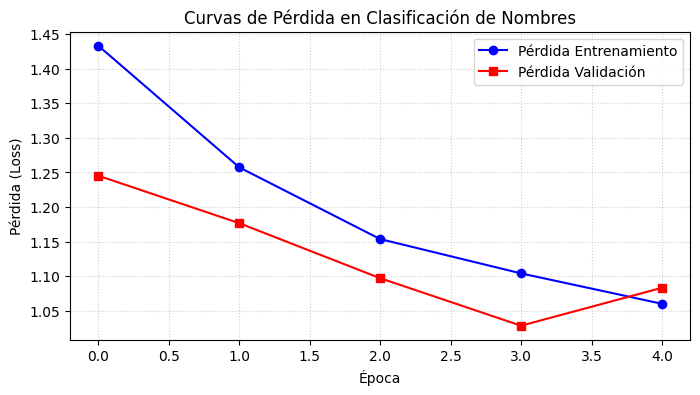

In [8]:
print("=== Entrenando RNN Básica ===")
rnn_modelo = RedRnnBasica(num_caracteres, tam_oculto=128, tam_salida=num_idiomas)
acc_rnn, f1_rnn = entrenar_y_evaluar_clasificador(
    rnn_modelo, dataset_entrenamiento, dataset_validacion, dataset_prueba, epocas=5, lr=0.001
)


=== Entrenando LSTM ===


Época 1/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [1/5] | Pérdida Train: 1.2766 | Pérdida Val: 1.0122


Época 2/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [2/5] | Pérdida Train: 0.9063 | Pérdida Val: 0.8152


...

Época [3/5] | Pérdida Train: 0.7279 | Pérdida Val: 0.7558


Época 4/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [4/5] | Pérdida Train: 0.6256 | Pérdida Val: 0.7616


Época 5/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [5/5] | Pérdida Train: 0.5321 | Pérdida Val: 0.8005

---> Rendimiento en el conjunto de prueba:
     Exactitud (Accuracy): 83.02%
     F1-Macro: 50.93%


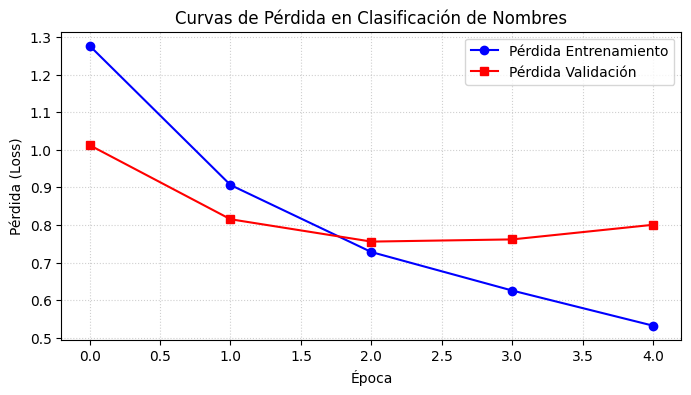

In [9]:
print("=== Entrenando LSTM ===")
lstm_modelo = RedLstm(num_caracteres, tam_oculto=128, tam_salida=num_idiomas)
acc_lstm, f1_lstm = entrenar_y_evaluar_clasificador(
    lstm_modelo, dataset_entrenamiento, dataset_validacion, dataset_prueba, epocas=5, lr=0.001
)


=== Entrenando GRU ===


Época 1/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [1/5] | Pérdida Train: 1.1853 | Pérdida Val: 0.9027


Época 2/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [2/5] | Pérdida Train: 0.8244 | Pérdida Val: 0.7671


...

Época [3/5] | Pérdida Train: 0.6726 | Pérdida Val: 0.7166


Época 4/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [4/5] | Pérdida Train: 0.5830 | Pérdida Val: 0.7408


Época 5/5 - Entrenando:   0%|          | 0/16058 [00:00<?, ?it/s]

Época [5/5] | Pérdida Train: 0.4998 | Pérdida Val: 0.7902

---> Rendimiento en el conjunto de prueba:
     Exactitud (Accuracy): 83.17%
     F1-Macro: 53.37%


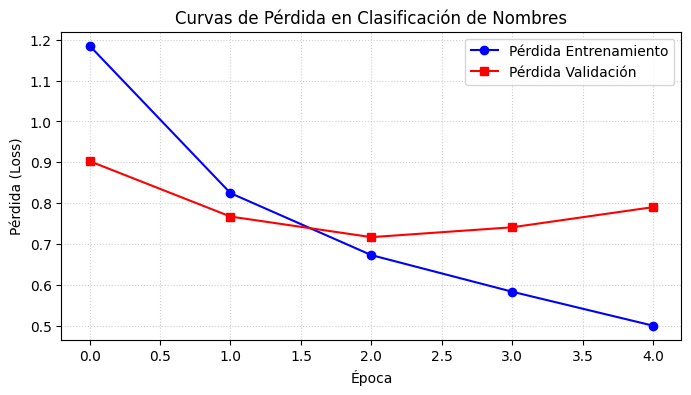

In [10]:
print("=== Entrenando GRU ===")
gru_modelo = RedGru(num_caracteres, tam_oculto=128, tam_salida=num_idiomas)
acc_gru, f1_gru = entrenar_y_evaluar_clasificador(
    gru_modelo, dataset_entrenamiento, dataset_validacion, dataset_prueba, epocas=5, lr=0.001
)


## **2.5 Comparativa de Modelos**


=== TABLA COMPARATIVA EN TEST ===
    Modelo  Exactitud (%)  F1-Macro (%)
RNN Básica      75.448207     33.776034
      LSTM      83.017928     50.927269
       GRU      83.167331     53.371389


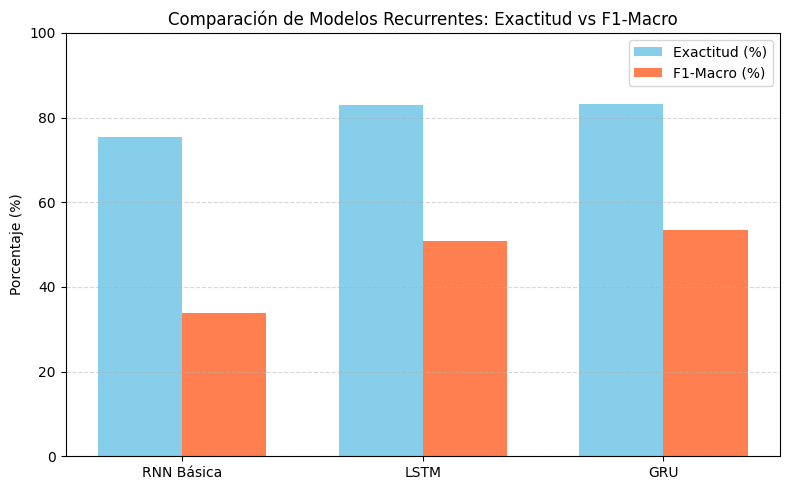

In [11]:
df_comparativo = pd.DataFrame({
    'Modelo': ['RNN Básica', 'LSTM', 'GRU'],
    'Exactitud (%)': [acc_rnn, acc_lstm, acc_gru],
    'F1-Macro (%)': [f1_rnn, f1_lstm, f1_gru]
})

print("=== TABLA COMPARATIVA EN TEST ===")
print(df_comparativo.to_string(index=False))

# Graficar los resultados comparativos
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_comparativo['Modelo']))
ancho = 0.35

ax.bar(x - ancho/2, df_comparativo['Exactitud (%)'], ancho, label='Exactitud (%)', color='skyblue')
ax.bar(x + ancho/2, df_comparativo['F1-Macro (%)'], ancho, label='F1-Macro (%)', color='coral')

ax.set_ylabel('Porcentaje (%)')
ax.set_title('Comparación de Modelos Recurrentes: Exactitud vs F1-Macro')
ax.set_xticks(x)
ax.set_xticklabels(df_comparativo['Modelo'])
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()


# **3. Parte II: Predicción de Calidad del Aire (Series de Tiempo)**

Utilizaremos redes LSTM para predecir la concentración de partículas PM2.5 en Beijing mediante dos aproximaciones:
1. **Univariada**: Usando solo los valores pasados de la serie (original vs. descompuesta con STL).
2. **Multivariada**: Incorporando variables meteorológicas y otros contaminantes.


## **3.1 Análisis Exploratorio y Descomposición STL**

Imputamos valores faltantes, remuestreamos la serie a escala diaria y aplicaremos la descomposición STL para separar tendencia y estacionalidad.


Primeras filas limpias con índice temporal:
                     PM2.5  TEMP    PRES  RAIN
datetime                                      
2013-03-01 00:00:00    4.0  -0.7  1023.0   0.0
2013-03-01 01:00:00    8.0  -1.1  1023.2   0.0
2013-03-01 02:00:00    7.0  -1.1  1023.5   0.0
2013-03-01 03:00:00    6.0  -1.4  1024.5   0.0
2013-03-01 04:00:00    3.0  -2.0  1025.2   0.0


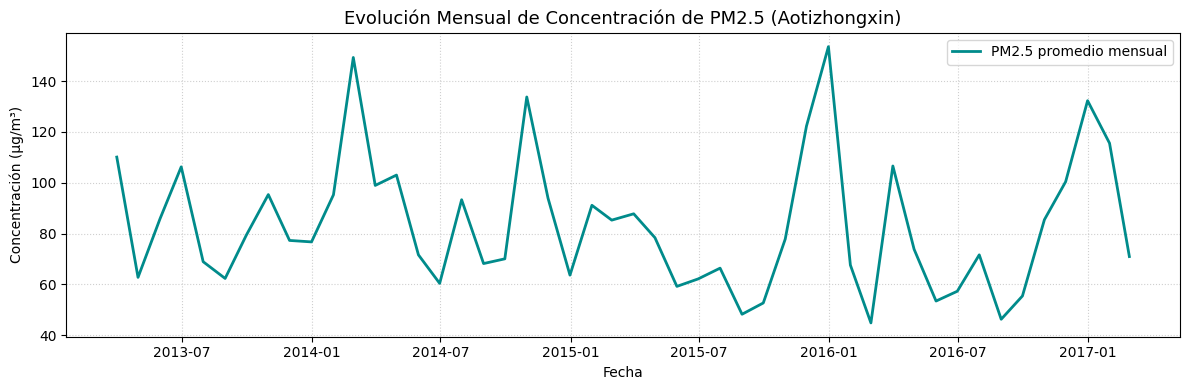

In [12]:
# Cargar el dataset de calidad del aire de Beijing
df_aire = pd.read_csv("data/PRSA_Data_Aotizhongxin_20130301-20170228.csv")

# Imputar valores nulos (ffill y bfill de forma sucesiva)
df_aire_limpio = df_aire.ffill().bfill()

# Generar columna de índice temporal datetime
df_aire_limpio['datetime'] = pd.to_datetime(df_aire_limpio[['year', 'month', 'day', 'hour']])
df_aire_limpio = df_aire_limpio.set_index('datetime')

# Verificación básica
print("Primeras filas limpias con índice temporal:")
print(df_aire_limpio[['PM2.5', 'TEMP', 'PRES', 'RAIN']].head())

# Agrupación mensual interactiva simulada en Matplotlib (promedio mensual)
df_num = df_aire_limpio.select_dtypes(include='number')
promedio_mensual = df_num.resample('ME').mean()

plt.figure(figsize=(12, 4))
plt.plot(promedio_mensual.index, promedio_mensual['PM2.5'], color='darkcyan', linewidth=2, label='PM2.5 promedio mensual')
plt.title('Evolución Mensual de Concentración de PM2.5 (Aotizhongxin)', fontsize=13)
plt.xlabel('Fecha')
plt.ylabel('Concentración (μg/m³)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


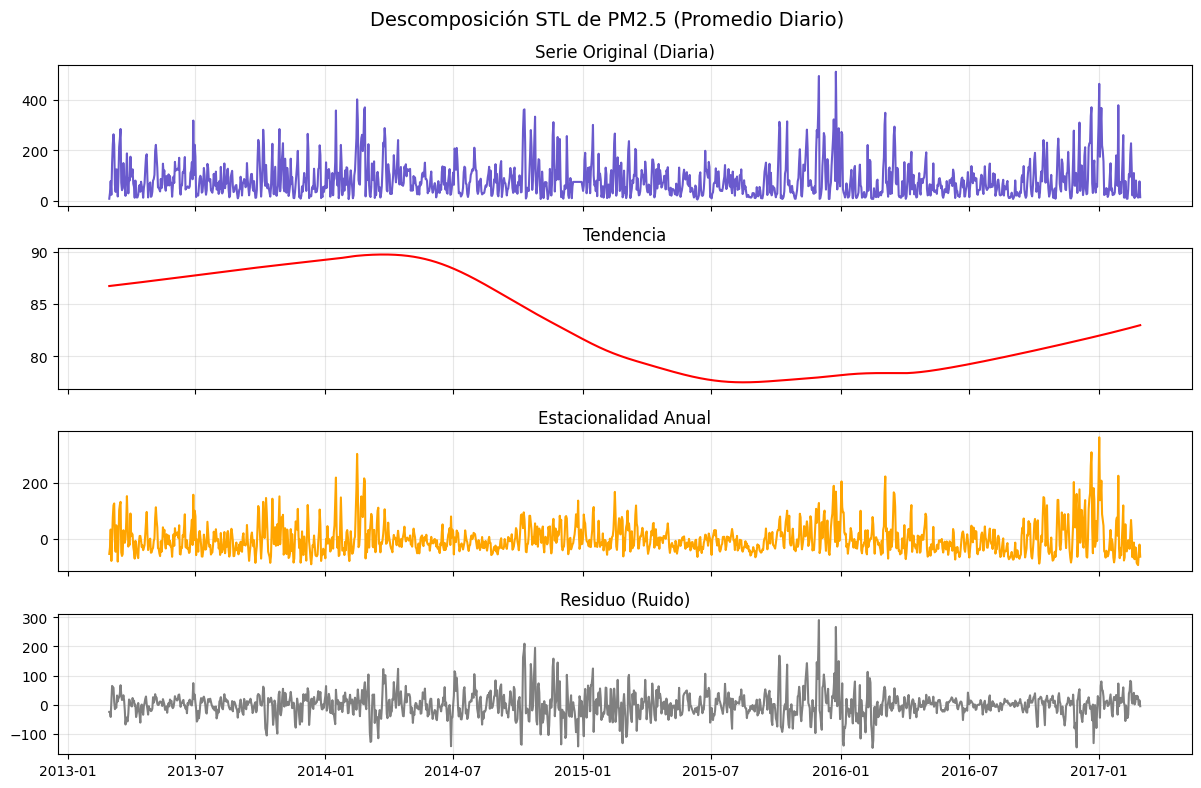

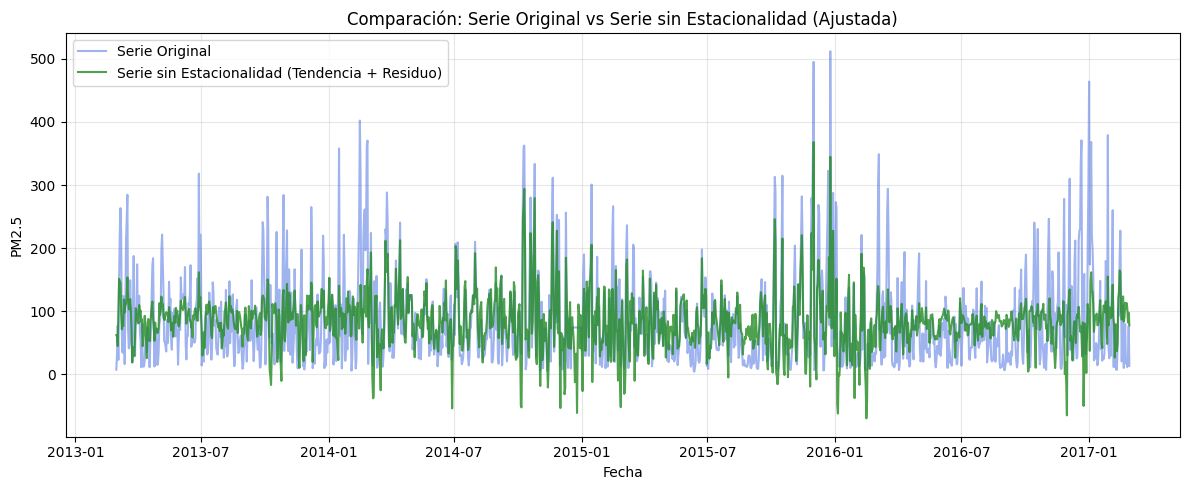

In [13]:
# Remuestreo a promedio diario para el análisis STL
serie_diaria = df_aire_limpio['PM2.5'].resample('D').mean()

# Aplicar la descomposición STL con periodo anual de 365 días
stl = STL(serie_diaria, period=365)
resultado_stl = stl.fit()

# Componentes de la descomposición
tendencia = resultado_stl.trend
estacionalidad = resultado_stl.seasonal
residuo = resultado_stl.resid

# Graficar los componentes en subplots con Matplotlib
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax1.plot(serie_diaria, color='slateblue')
ax1.set_title("Serie Original (Diaria)")
ax1.grid(True, alpha=0.3)

ax2.plot(tendencia, color='red')
ax2.set_title("Tendencia")
ax2.grid(True, alpha=0.3)

ax3.plot(estacionalidad, color='orange')
ax3.set_title("Estacionalidad Anual")
ax3.grid(True, alpha=0.3)

ax4.plot(residuo, color='gray')
ax4.set_title("Residuo (Ruido)")
ax4.grid(True, alpha=0.3)

plt.suptitle("Descomposición STL de PM2.5 (Promedio Diario)", fontsize=14)
plt.tight_layout()
plt.show()

# Crear serie ajustada sin estacionalidad
serie_sin_estacionalidad = tendencia + residuo

# Comparación visual de las series
plt.figure(figsize=(12, 5))
plt.plot(serie_diaria, label='Serie Original', alpha=0.5, color='royalblue')
plt.plot(serie_sin_estacionalidad, label='Serie sin Estacionalidad (Tendencia + Residuo)', alpha=0.8, color='forestgreen')
plt.title('Comparación: Serie Original vs Serie sin Estacionalidad (Ajustada)')
plt.xlabel('Fecha')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## **3.2 Predicción Univariada con LSTM (Original vs. Sin Estacionalidad)**

Entrenaremos modelos LSTM univariados usando secuencias de 30 días. Dividiremos cronológicamente los datos (80/10/10) y normalizaremos con `MinMaxScaler` ajustado únicamente en el conjunto de entrenamiento para evitar la fuga de datos (*data leakage*).


In [14]:
def crear_secuencias_univariables(datos, ventana):
    """Genera secuencias de entrada de tamaño (ventana) y su respectiva salida a predecir."""
    X, y = [], []
    for i in range(len(datos) - ventana):
        X.append(datos[i:i+ventana])
        y.append(datos[i+ventana])
    return np.array(X), np.array(y)

# Remuestreo diario
datos_originales = serie_diaria.values.reshape(-1, 1)
datos_ajustados = serie_sin_estacionalidad.values.reshape(-1, 1)

tam_ventana = 30
X_orig_raw, y_orig_raw = crear_secuencias_univariables(datos_originales, tam_ventana)
X_adj_raw, y_adj_raw = crear_secuencias_univariables(datos_ajustados, tam_ventana)

def dividir_datos_temporalmente(X, y, prop_train=0.8, prop_val=0.1):
    """Divide los datos cronológicamente en entrenamiento, validación y prueba."""
    n = len(X)
    lim_train = int(n * prop_train)
    lim_val = int(n * (prop_train + prop_val))
    
    X_train = X[:lim_train]
    y_train = y[:lim_train]
    X_val = X[lim_train:lim_val]
    y_val = y[lim_train:lim_val]
    X_test = X[lim_val:]
    y_test = y[lim_val:]
    return X_train, X_val, X_test, y_train, y_val, y_test

# Dividir datos originales y ajustados
Xo_train_raw, Xo_val_raw, Xo_test_raw, yo_train_raw, yo_val_raw, yo_test_raw = dividir_datos_temporalmente(X_orig_raw, y_orig_raw)
Xa_train_raw, Xa_val_raw, Xa_test_raw, ya_train_raw, ya_val_raw, ya_test_raw = dividir_datos_temporalmente(X_adj_raw, y_adj_raw)

# Normalización libre de fugas de datos (Data Leakage)
scaler_orig = MinMaxScaler()
scaler_orig.fit(yo_train_raw)  # Ajustar solo con el conjunto de entrenamiento

scaler_adj = MinMaxScaler()
scaler_adj.fit(ya_train_raw)  # Ajustar solo con el conjunto de entrenamiento

def normalizar_secuencia(X_raw, y_raw, scaler):
    """Normaliza X e y utilizando un escalador MinMaxScaler ya ajustado."""
    N, vent, features = X_raw.shape
    X_reshaped = X_raw.reshape(-1, features)
    X_scaled = scaler.transform(X_reshaped).reshape(N, vent, features)
    y_scaled = scaler.transform(y_raw)
    return X_scaled, y_scaled

Xo_train, yo_train = normalizar_secuencia(Xo_train_raw, yo_train_raw, scaler_orig)
Xo_val, yo_val = normalizar_secuencia(Xo_val_raw, yo_val_raw, scaler_orig)
Xo_test, yo_test = normalizar_secuencia(Xo_test_raw, yo_test_raw, scaler_orig)

Xa_train, ya_train = normalizar_secuencia(Xa_train_raw, ya_train_raw, scaler_adj)
Xa_val, ya_val = normalizar_secuencia(Xa_val_raw, ya_val_raw, scaler_adj)
Xa_test, ya_test = normalizar_secuencia(Xa_test_raw, ya_test_raw, scaler_adj)

# Dataset personalizado para PyTorch Dataloaders
class DatasetSecuencias(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoaders
tam_lote = 64
loader_o_train = DataLoader(DatasetSecuencias(Xo_train, yo_train), batch_size=tam_lote, shuffle=True)
loader_o_val = DataLoader(DatasetSecuencias(Xo_val, yo_val), batch_size=tam_lote, shuffle=False)
loader_o_test = DataLoader(DatasetSecuencias(Xo_test, yo_test), batch_size=tam_lote, shuffle=False)

loader_a_train = DataLoader(DatasetSecuencias(Xa_train, ya_train), batch_size=tam_lote, shuffle=True)
loader_a_val = DataLoader(DatasetSecuencias(Xa_val, ya_val), batch_size=tam_lote, shuffle=False)
loader_a_test = DataLoader(DatasetSecuencias(Xa_test, ya_test), batch_size=tam_lote, shuffle=False)

print(f"Secuencias de Entrenamiento (Original): {len(Xo_train)}")
print(f"Secuencias de Validación (Original): {len(Xo_val)}")
print(f"Secuencias de Prueba (Original): {len(Xo_test)}")


Secuencias de Entrenamiento (Original): 1144
Secuencias de Validación (Original): 143
Secuencias de Prueba (Original): 144


In [15]:
class ModeloLstmUnivariable(nn.Module):
    """Modelo LSTM simple para predicción univariable."""
    def __init__(self, tam_entrada=1, tam_oculto=50):
        super(ModeloLstmUnivariable, self).__init__()
        # batch_first=True indica que las entradas vienen como (lote, seq, feature)
        self.lstm = nn.LSTM(tam_entrada, tam_oculto, batch_first=True)
        self.capa_lineal = nn.Linear(tam_oculto, 1)

    def forward(self, x):
        salida_lstm, _ = self.lstm(x)
        # Tomamos el estado oculto final de la ventana de tiempo
        return self.capa_lineal(salida_lstm[:, -1, :])

def entrenar_y_evaluar_pronostico(loader_train, loader_val, loader_test, scaler, epocas=20, lr=0.001, desc=""):
    """Entrena la LSTM y evalúa sobre validación y prueba, devolviendo MSE y MAE en la escala real."""
    modelo = ModeloLstmUnivariable().to(dispositivo)
    criterio = nn.MSELoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    
    historial_train = []
    historial_val = []
    
    # Barra de progreso por épocas
    progreso = tqdm(range(epocas), desc=f"LSTM - {desc}")
    for epoca in progreso:
        # Modo entrenamiento
        modelo.train()
        loss_acum_train = 0.0
        for xb, yb in loader_train:
            xb, yb = xb.to(dispositivo), yb.to(dispositivo)
            
            pred = modelo(xb)
            loss = criterio(pred, yb)
            
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()
            
            loss_acum_train += loss.item()
            
        perdida_train = loss_acum_train / len(loader_train)
        historial_train.append(perdida_train)
        
        # Modo validación
        modelo.eval()
        loss_acum_val = 0.0
        with torch.no_grad():
            for xb, yb in loader_val:
                xb, yb = xb.to(dispositivo), yb.to(dispositivo)
                pred = modelo(xb)
                loss = criterio(pred, yb)
                loss_acum_val += loss.item()
                
        perdida_val = loss_acum_val / len(loader_val)
        historial_val.append(perdida_val)
        
        progreso.set_postfix(train_loss=f"{perdida_train:.4f}", val_loss=f"{perdida_val:.4f}")
        
    # Evaluación final en prueba
    modelo.eval()
    y_scaled_reales = []
    y_scaled_preds = []
    
    with torch.no_grad():
        for xb, yb in loader_test:
            xb = xb.to(dispositivo)
            pred = modelo(xb)
            y_scaled_reales.extend(yb.cpu().numpy())
            y_scaled_preds.extend(pred.cpu().numpy())
            
    # Invertir normalización para evaluar en la escala física real (μg/m³)
    y_reales = scaler.inverse_transform(np.array(y_scaled_reales).reshape(-1, 1))
    y_preds = scaler.inverse_transform(np.array(y_scaled_preds).reshape(-1, 1))
    
    mse = mean_squared_error(y_reales, y_preds)
    mae = mean_absolute_error(y_reales, y_preds)
    
    print(f"\n---> Resultados LSTM {desc} (Escala Real):")
    print(f"     Pérdida Cuadrática Media (MSE): {mse:.4f}")
    print(f"     Error Absoluto Medio (MAE): {mae:.4f}\n")
    
    return mse, mae, y_reales, y_preds


In [16]:
# 1. Entrenar y evaluar con la Serie Original
mse_orig, mae_orig, y_reales_o, y_preds_o = entrenar_y_evaluar_pronostico(
    loader_o_train, loader_o_val, loader_o_test, scaler_orig, epocas=20, lr=0.001, desc="Serie Original"
)

# 2. Entrenar y evaluar con la Serie sin Estacionalidad (Ajustada)
mse_adj, mae_adj, y_reales_a, y_preds_a = entrenar_y_evaluar_pronostico(
    loader_a_train, loader_a_val, loader_a_test, scaler_adj, epocas=20, lr=0.001, desc="Serie Ajustada (Sin Estacionalidad)"
)


LSTM - Serie Original:   0%|          | 0/20 [00:00<?, ?it/s]


---> Resultados LSTM Serie Original (Escala Real):
     Pérdida Cuadrática Media (MSE): 6144.3140
     Error Absoluto Medio (MAE): 56.5849



LSTM - Serie Ajustada (Sin Estacionalidad):   0%|          | 0/20 [00:00<?, ?it/s]


---> Resultados LSTM Serie Ajustada (Sin Estacionalidad) (Escala Real):
     Pérdida Cuadrática Media (MSE): 1202.1703
     Error Absoluto Medio (MAE): 24.6534



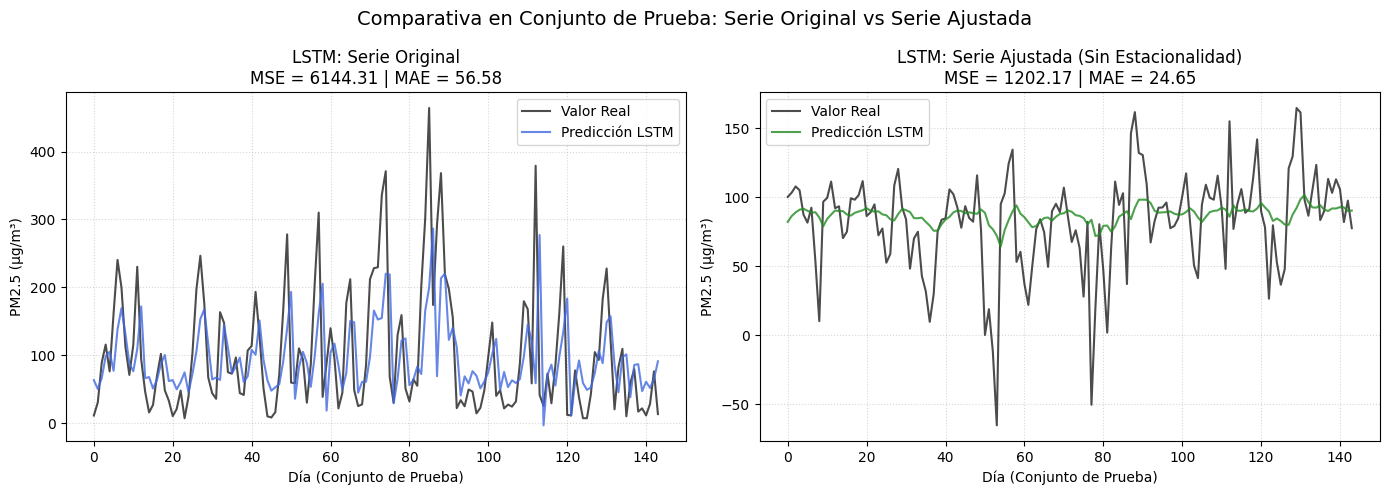

In [17]:
# Graficar los resultados comparativos en prueba para ambos modelos univariados
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_reales_o, label='Valor Real', color='black', alpha=0.7)
plt.plot(y_preds_o, label='Predicción LSTM', color='royalblue', alpha=0.8)
plt.title(f'LSTM: Serie Original\nMSE = {mse_orig:.2f} | MAE = {mae_orig:.2f}')
plt.xlabel('Día (Conjunto de Prueba)')
plt.ylabel('PM2.5 (μg/m³)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_reales_a, label='Valor Real', color='black', alpha=0.7)
plt.plot(y_preds_a, label='Predicción LSTM', color='forestgreen', alpha=0.8)
plt.title(f'LSTM: Serie Ajustada (Sin Estacionalidad)\nMSE = {mse_adj:.2f} | MAE = {mae_adj:.2f}')
plt.xlabel('Día (Conjunto de Prueba)')
plt.ylabel('PM2.5 (μg/m³)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

plt.suptitle('Comparativa en Conjunto de Prueba: Serie Original vs Serie Ajustada', fontsize=14)
plt.tight_layout()
plt.show()


## **3.3 Predicción Multivariable con LSTM**

Incorporamos otras variables meteorológicas y contaminantes como entrada. Para evitar fugas de datos, escalamos la entrada X y el objetivo y de manera independiente y únicamente con las estadísticas de entrenamiento.


In [18]:
# Selección de variables y construcción del DataFrame multivariado diario
variables_input = ['SO2', 'NO2', 'CO', 'O3', 'TEMP', 'DEWP', 'PRES', 'RAIN', 'WSPM']
variable_target = 'PM2.5'

df_mv = df_aire_limpio[[variable_target] + variables_input].resample('D').mean().ffill()
datos_mv = df_mv.values  # Array de tamaño (días, features) -> Columna 0 es PM2.5

def crear_secuencias_multivariables(datos, ventana):
    """Crea ventanas de tiempo con múltiples variables de entrada y un único target."""
    X, y = [], []
    for i in range(len(datos) - ventana):
        # Las columnas inputs son de la 1 en adelante
        X.append(datos[i:i+ventana, 1:])
        # El target PM2.5 está en la columna 0 en el día (i+ventana)
        y.append(datos[i+ventana, 0])
    return np.array(X), np.array(y)

tam_ventana_mv = 60
X_mv_raw, y_mv_raw = crear_secuencias_multivariables(datos_mv, tam_ventana_mv)

# División temporal (80% Train, 10% Val, 10% Test)
Xm_train_raw, Xm_val_raw, Xm_test_raw, ym_train_raw, ym_val_raw, ym_test_raw = dividir_datos_temporalmente(X_mv_raw, y_mv_raw)

# Escaladores separados para entradas y target (Libre de Data Leakage)
scaler_X_mv = MinMaxScaler()
scaler_y_mv = MinMaxScaler()

# Ajustar los escaladores solo en el conjunto de entrenamiento
N_tr, vent_tr, feat_tr = Xm_train_raw.shape
scaler_X_mv.fit(Xm_train_raw.reshape(-1, feat_tr))
scaler_y_mv.fit(ym_train_raw.reshape(-1, 1))

def normalizar_secuencia_multivariable(X_raw, y_raw, scaler_x, scaler_y):
    """Normaliza X e y para el flujo multivariable usando escaladores ajustados."""
    N, vent, feat = X_raw.shape
    X_scaled = scaler_x.transform(X_raw.reshape(-1, feat)).reshape(N, vent, feat)
    y_scaled = scaler_y.transform(y_raw.reshape(-1, 1))
    return X_scaled, y_scaled

Xm_train, ym_train = normalizar_secuencia_multivariable(Xm_train_raw, ym_train_raw, scaler_X_mv, scaler_y_mv)
Xm_val, ym_val = normalizar_secuencia_multivariable(Xm_val_raw, ym_val_raw, scaler_X_mv, scaler_y_mv)
Xm_test, ym_test = normalizar_secuencia_multivariable(Xm_test_raw, ym_test_raw, scaler_X_mv, scaler_y_mv)

# Crear loaders
loader_m_train = DataLoader(DatasetSecuencias(Xm_train, ym_train), batch_size=tam_lote, shuffle=True)
loader_m_val = DataLoader(DatasetSecuencias(Xm_val, ym_val), batch_size=tam_lote, shuffle=False)
loader_m_test = DataLoader(DatasetSecuencias(Xm_test, ym_test), batch_size=tam_lote, shuffle=False)

print(f"Muestras Multivariables para Entrenamiento: {len(Xm_train)}")
print(f"Muestras Multivariables para Validación: {len(Xm_val)}")
print(f"Muestras Multivariables para Prueba: {len(Xm_test)}")


Muestras Multivariables para Entrenamiento: 1120
Muestras Multivariables para Validación: 140
Muestras Multivariables para Prueba: 141


In [19]:
class ModeloLstmMultivariable(nn.Module):
    """Modelo LSTM diseñado para recibir múltiples características de entrada."""
    def __init__(self, tam_entrada, tam_oculto=50):
        super(ModeloLstmMultivariable, self).__init__()
        self.lstm = nn.LSTM(input_size=tam_entrada, hidden_size=tam_oculto, batch_first=True)
        self.capa_lineal = nn.Linear(tam_oculto, 1)

    def forward(self, x):
        salida_lstm, _ = self.lstm(x)
        # Extraer el estado oculto del último paso de tiempo
        return self.capa_lineal(salida_lstm[:, -1, :])

def entrenar_y_evaluar_multivariable(loader_train, loader_val, loader_test, scaler_y, epocas=20, lr=0.001):
    """Entrena y evalúa el modelo LSTM multivariable."""
    # Obtener el número de características de entrada
    tam_entrada = loader_train.dataset.X.shape[-1]
    
    modelo = ModeloLstmMultivariable(tam_entrada=tam_entrada).to(dispositivo)
    criterio = nn.MSELoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    
    historial_train = []
    historial_val = []
    
    progreso = tqdm(range(epocas), desc="LSTM Multivariable")
    for epoca in progreso:
        # Entrenamiento
        modelo.train()
        loss_acum_train = 0.0
        for xb, yb in loader_train:
            xb, yb = xb.to(dispositivo), yb.to(dispositivo)
            
            pred = modelo(xb)
            loss = criterio(pred, yb)
            
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()
            
            loss_acum_train += loss.item()
            
        perdida_train = loss_acum_train / len(loader_train)
        historial_train.append(perdida_train)
        
        # Validación
        modelo.eval()
        loss_acum_val = 0.0
        with torch.no_grad():
            for xb, yb in loader_val:
                xb, yb = xb.to(dispositivo), yb.to(dispositivo)
                pred = modelo(xb)
                loss = criterio(pred, yb)
                loss_acum_val += loss.item()
                
        perdida_val = loss_acum_val / len(loader_val)
        historial_val.append(perdida_val)
        
        progreso.set_postfix(train_loss=f"{perdida_train:.4f}", val_loss=f"{perdida_val:.4f}")
        
    # Evaluar en Test
    modelo.eval()
    y_scaled_reales = []
    y_scaled_preds = []
    
    with torch.no_grad():
        for xb, yb in loader_test:
            xb = xb.to(dispositivo)
            pred = modelo(xb)
            y_scaled_reales.extend(yb.cpu().numpy())
            y_scaled_preds.extend(pred.cpu().numpy())
            
    # Invertir normalización del target PM2.5 usando su scaler específico
    y_reales = scaler_y.inverse_transform(np.array(y_scaled_reales).reshape(-1, 1))
    y_preds = scaler_y.inverse_transform(np.array(y_scaled_preds).reshape(-1, 1))
    
    mse = mean_squared_error(y_reales, y_preds)
    # Asegurarse de no reportar valores negativos físicos causados por oscilaciones en la red
    y_preds = np.clip(y_preds, 0, None)
    mae = mean_absolute_error(y_reales, y_preds)
    
    print("\n---> Resultados LSTM Multivariable (Escala Real):")
    print(f"     Pérdida Cuadrática Media (MSE): {mse:.4f}")
    print(f"     Error Absoluto Medio (MAE): {mae:.4f}\n")
    
    return mse, mae, y_reales, y_preds


LSTM Multivariable:   0%|          | 0/20 [00:00<?, ?it/s]


---> Resultados LSTM Multivariable (Escala Real):
     Pérdida Cuadrática Media (MSE): 5269.7285
     Error Absoluto Medio (MAE): 53.4908



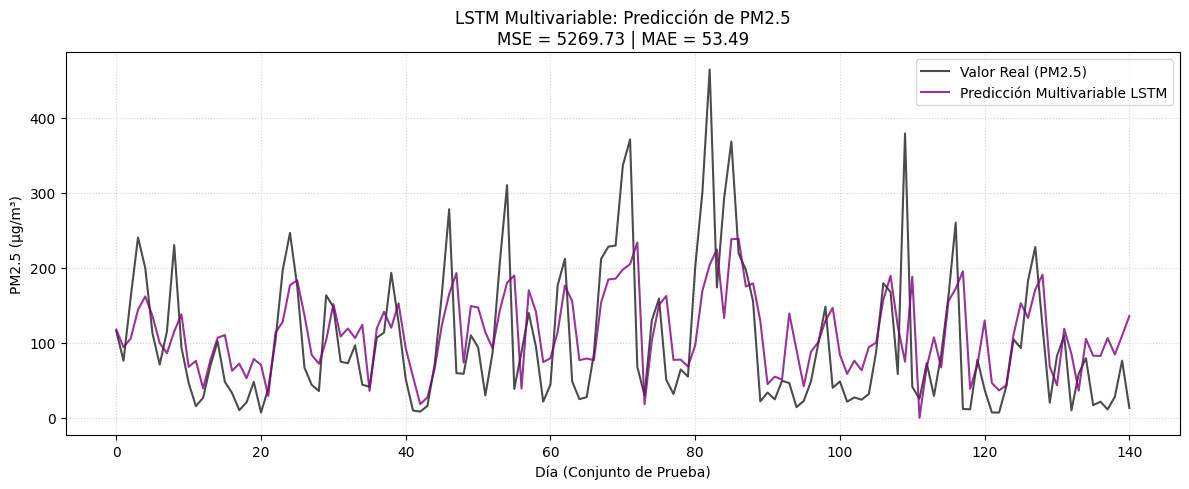

In [20]:
# Entrenar y evaluar el modelo multivariable
mse_mv, mae_mv, y_reales_mv, y_preds_mv = entrenar_y_evaluar_multivariable(
    loader_m_train, loader_m_val, loader_m_test, scaler_y_mv, epocas=20, lr=0.001
)

# Graficar los resultados del modelo multivariable en el conjunto de prueba con Matplotlib
plt.figure(figsize=(12, 5))
plt.plot(y_reales_mv, label='Valor Real (PM2.5)', color='black', alpha=0.7)
plt.plot(y_preds_mv, label='Predicción Multivariable LSTM', color='purple', alpha=0.8)
plt.title(f'LSTM Multivariable: Predicción de PM2.5\nMSE = {mse_mv:.2f} | MAE = {mae_mv:.2f}')
plt.xlabel('Día (Conjunto de Prueba)')
plt.ylabel('PM2.5 (μg/m³)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
